<a href="https://colab.research.google.com/github/electiva1995-2026/datamining/blob/main/CasoPractico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CASO PRÁCTICO APLICADO

Técnicas de Producción Industrial de Software

6. Actividades a desarrollar
Actividad 1. Preparación e inspección inicial del dataset


In [1]:
import pandas as pd

In [13]:
df = pd.read_csv('https://raw.githubusercontent.com/electiva1995-2026/datamining/refs/heads/main/Caso_Practico_Aplicado/Prestige_modificado.csv', sep=';')


In [3]:
print(df.shape)

(102, 1)


In [4]:
print(df.head())

  occupation;education;income;women;prestige;census;type_num
0   gov.administrators;13.11;12351;11.16;68.8;1113;1        
1      general.managers;12.26;25879;4.02;69.1;1130;1        
2            accountants;12.77;9271;15.7;63.4;1171;1        
3    purchasing.officers;11.42;8865;9.11;56.8;1175;1        
4              chemists;14.62;8403;11.68;73.5;2111;1        


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 1 columns):
 #   Column                                                      Non-Null Count  Dtype 
---  ------                                                      --------------  ----- 
 0   occupation;education;income;women;prestige;census;type_num  102 non-null    object
dtypes: object(1)
memory usage: 948.0+ bytes
None


In [6]:
print(df.isnull().sum())

occupation;education;income;women;prestige;census;type_num    0
dtype: int64


In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df.describe())

       occupation;education;income;women;prestige;census;type_num
count                                                 102        
unique                                                102        
top      gov.administrators;13.11;12351;11.16;68.8;1113;1        
freq                                                    1        


Actividad 2. Análisis de relación entre variables

In [14]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()


In [15]:
print(matriz_correlacion.round(3))
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


Actividad 3. Visualización de resultados

In [16]:
import matplotlib.pyplot as plt

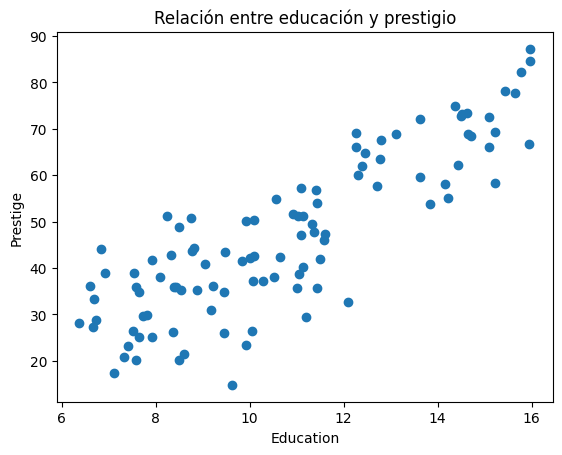

In [26]:
plt.figure()
plt.scatter(df['education'], df['prestige'])
plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Relación entre educación y prestigio')
plt.show()


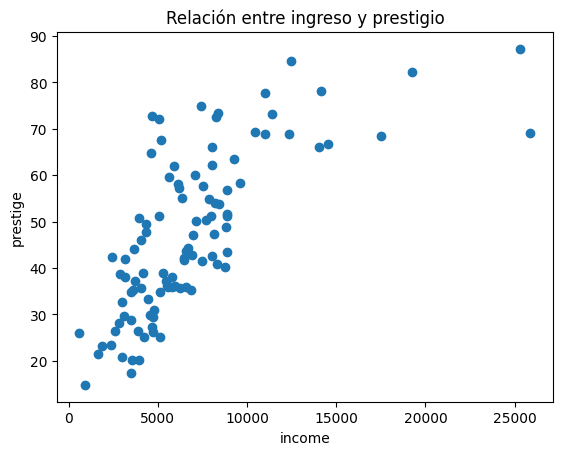

In [28]:
plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('income')
plt.ylabel('prestige')
plt.title('Relación entre ingreso y prestigio')
plt.show()


Actividad 4. Análisis de agrupación de ocupaciones

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [37]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

In [38]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)


In [39]:
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)


In [40]:
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)


In [41]:
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
